In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import shap
import joblib
import json
import warnings
warnings.filterwarnings("ignore")

# Load models and config
xgb_model = joblib.load("models/xgb_model.pkl")
lgb_model  = joblib.load("models/lgb_model.pkl")

with open("models/model_config.json", "r") as f:
    model_config = json.load(f)

FEATURE_COLS = model_config["feature_cols"]

# Load feature matrix for background data
df = pd.read_csv("features.csv")
X  = df[FEATURE_COLS].copy()

print("✅ Everything loaded")
print(f"   Features: {len(FEATURE_COLS)}")
print(f"   Riders:   {len(X)}")

✅ Everything loaded
   Features: 54
   Riders:   1000


In [2]:
!pip install shap

  Using cached shap-0.51.0-cp313-cp313-win_amd64.whl.metadata (26 kB)
  Using cached slicer-0.0.8-py3-none-any.whl.metadata (4.0 kB)
Using cached shap-0.51.0-cp313-cp313-win_amd64.whl (555 kB)
Using cached slicer-0.0.8-py3-none-any.whl (15 kB)

   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------------------------

In [4]:

# TreeExplainer is specifically designed for tree-based models

explainer = shap.TreeExplainer(xgb_model)

# Calculate SHAP values for all 1000 riders
# This gives us the full picture of how the model thinks
shap_values = explainer.shap_values(X)



Creating SHAP explainer...
This may take 30-60 seconds...

✅ SHAP explainer created
   SHAP values shape: (1000, 54)
   One row per rider, one column per feature
   Positive value = pushed score toward default
   Negative value = pushed score away from default


TOP 15 MOST IMPORTANT FEATURES
(across all 1,000 riders)

  Feature                               Importance
  --------------------------------------------------
  ever_defaulted                        0.2124  █████████████████████
  max_loan_repaid                       0.2021  ████████████████████
  sacco_contribution_rate               0.1670  ████████████████
  bike_owned                            0.1484  ██████████████
  segment_risk_score                    0.1057  ██████████
  family_remittance_monthly             0.0990  █████████
  min_mpesa_balance                     0.0929  █████████
  sacco_tenure_months                   0.0876  ████████
  debt_service_ratio                    0.0783  ███████
  sacco_contrib_monthly                 0.0686  ██████
  sacco_on_time_rate                    0.0661  ██████
  income_volatility_cv                  0.0587  █████
  total_loans_taken                     0.0573  █████
  rain_season_dip                       0.0558  █████
  fuel_to_i

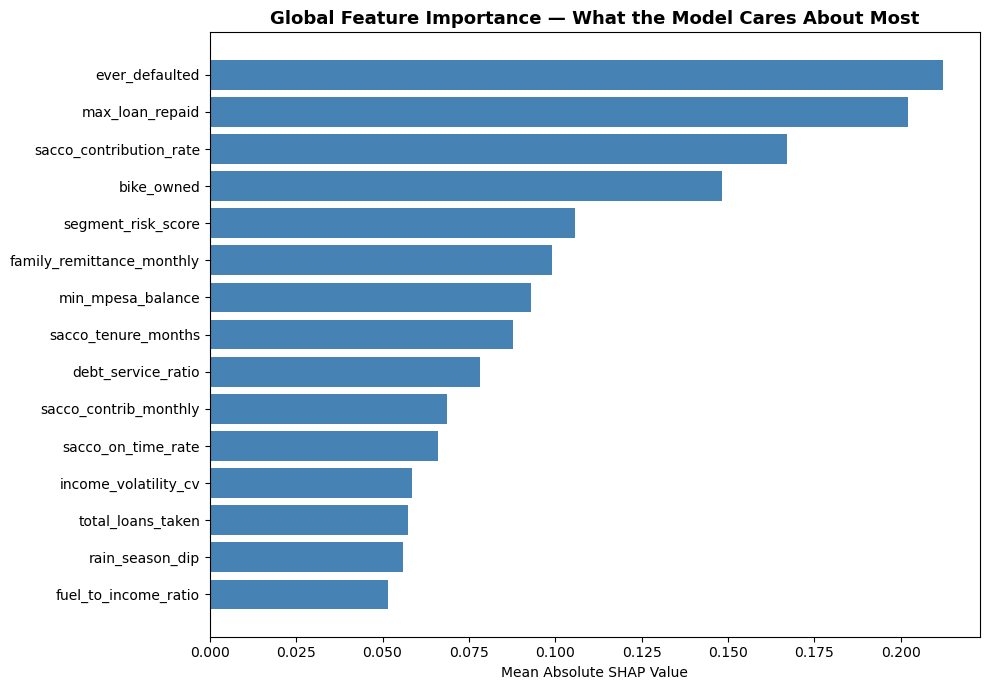

✅ Saved: shap_global_importance.png


In [5]:
# Calculate mean absolute SHAP value per feature
# Higher = more important across all riders
feature_importance = pd.DataFrame({
    "feature": FEATURE_COLS,
    "importance": np.abs(shap_values).mean(axis=0)
}).sort_values("importance", ascending=False)

print("TOP 15 MOST IMPORTANT FEATURES")
print("(across all 1,000 riders)")
print()
print(f"  {'Feature':<35} {'Importance':>12}")
print("  " + "-" * 50)
for _, row in feature_importance.head(15).iterrows():
    bar = "█" * int(row["importance"] * 100)
    print(f"  {row['feature']:<35} {row['importance']:>8.4f}  {bar}")

# Plot
plt.figure(figsize=(10, 7))
top_features = feature_importance.head(15)
plt.barh(top_features["feature"], top_features["importance"],
         color="steelblue")
plt.title("Global Feature Importance — What the Model Cares About Most",
          fontsize=13, fontweight="bold")
plt.xlabel("Mean Absolute SHAP Value")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig("shap_global_importance.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Saved: shap_global_importance.png")

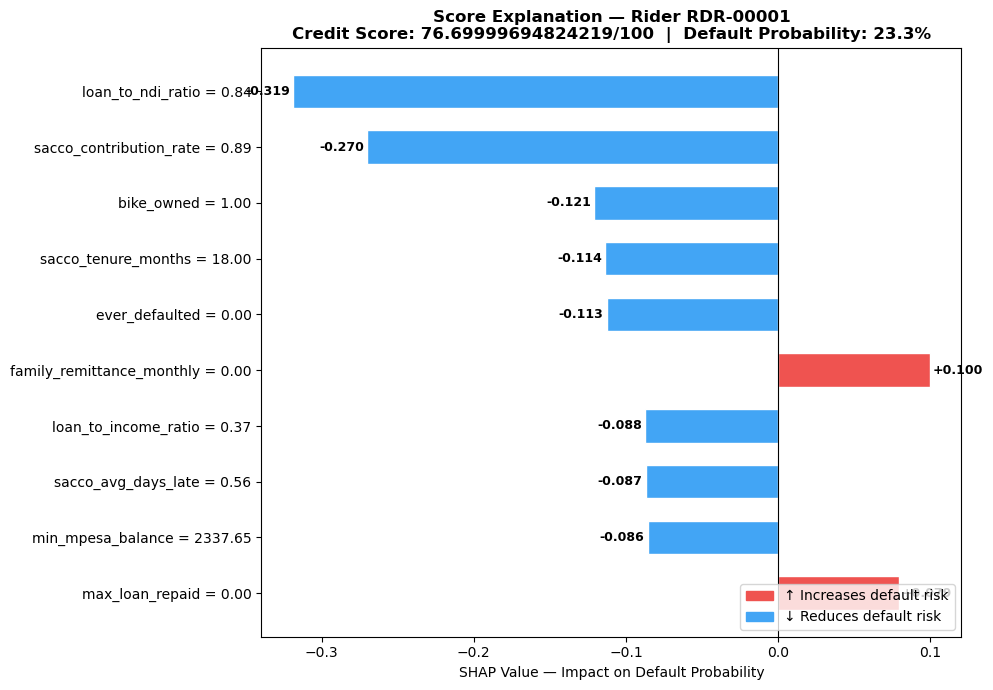

✅ Saved: shap_waterfall_rider.png


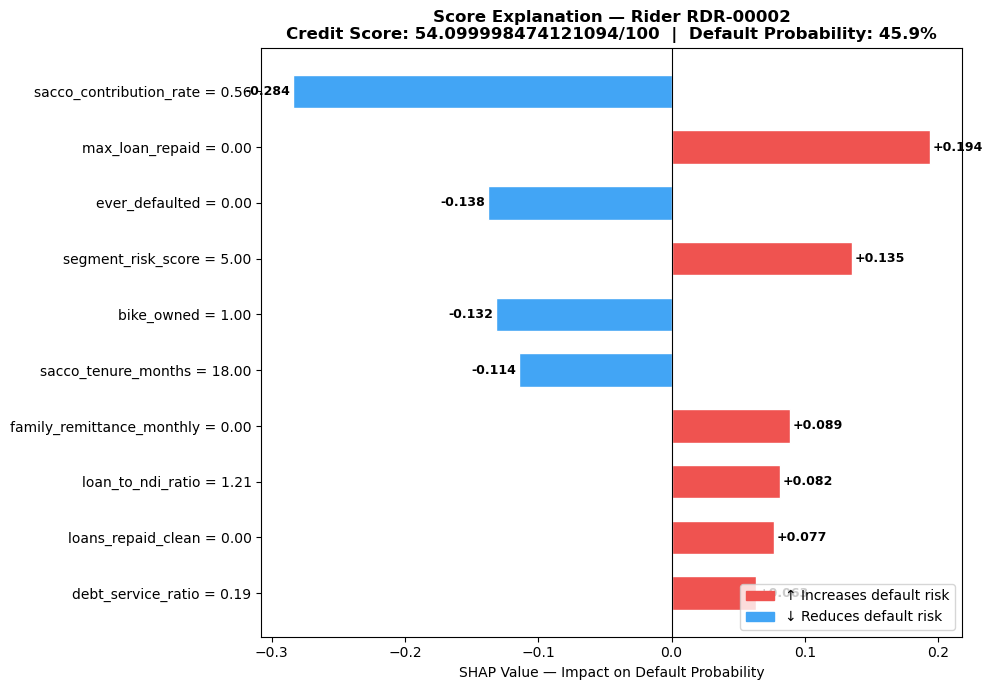

✅ Saved: shap_waterfall_rider.png


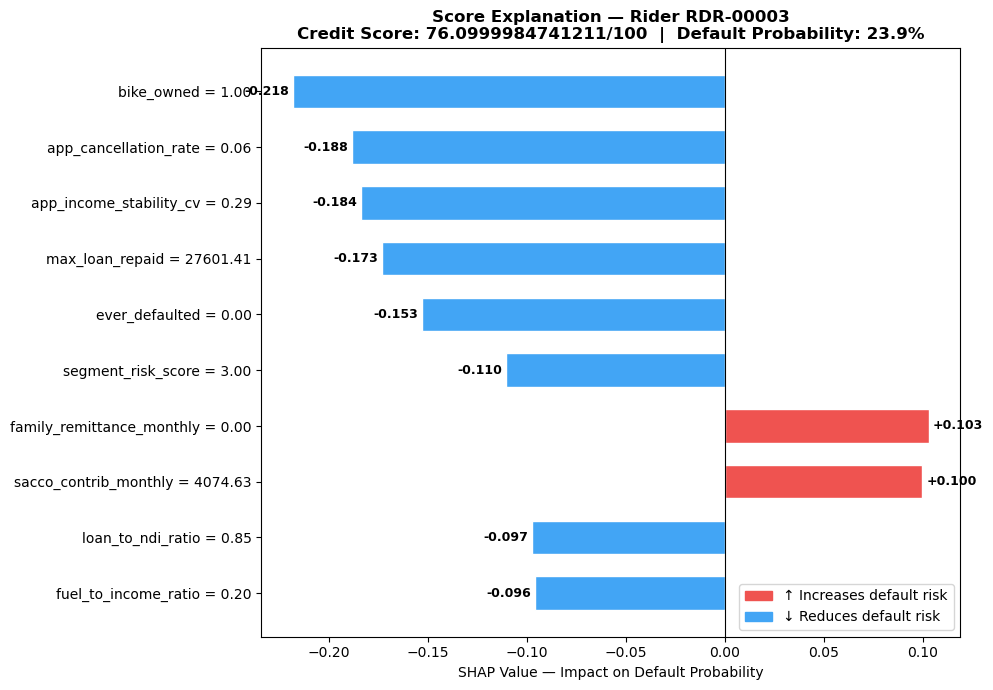

✅ Saved: shap_waterfall_rider.png


In [6]:
def plot_shap_waterfall(rider_index, rider_name):
    """
    Plot a waterfall chart showing what drove this rider's score.
    rider_index: position in the feature matrix (0 to 999)
    rider_name:  name to display on chart
    """

    # Get this rider's SHAP values
    rider_shap  = shap_values[rider_index]
    rider_feats = X.iloc[rider_index]

    # Get predicted probability
    pd_prob     = xgb_model.predict_proba(
        X.iloc[[rider_index]]
    )[0][1]
    credit_score = round(100 - pd_prob * 100, 1)

    # Sort features by absolute SHAP value — biggest impact first
    shap_df = pd.DataFrame({
        "feature": FEATURE_COLS,
        "shap_value": rider_shap,
        "feature_value": rider_feats.values,
    }).reindex(pd.Series(np.abs(rider_shap)).sort_values(ascending=False).index)

    # Take top 10 features for readability
    top_shap = shap_df.head(10)

    # Plot
    fig, ax = plt.subplots(figsize=(10, 7))

    colors = ["#ef5350" if v > 0 else "#42a5f5"
              for v in top_shap["shap_value"]]

    bars = ax.barh(
        range(len(top_shap)),
        top_shap["shap_value"],
        color=colors,
        height=0.6,
        edgecolor="white"
    )

    # Add feature labels with values
    labels = [
        f"{row['feature']} = {row['feature_value']:.2f}"
        for _, row in top_shap.iterrows()
    ]
    ax.set_yticks(range(len(top_shap)))
    ax.set_yticklabels(labels, fontsize=10)
    ax.invert_yaxis()

    # Add value labels on bars
    for i, (bar, val) in enumerate(zip(bars, top_shap["shap_value"])):
        ax.text(
            val + (0.002 if val > 0 else -0.002),
            i,
            f"{val:+.3f}",
            va="center",
            ha="left" if val > 0 else "right",
            fontsize=9,
            fontweight="bold"
        )

    ax.axvline(x=0, color="black", linewidth=0.8)

    # Legend
    red_patch  = mpatches.Patch(color="#ef5350",
                                 label="↑ Increases default risk")
    blue_patch = mpatches.Patch(color="#42a5f5",
                                 label="↓ Reduces default risk")
    ax.legend(handles=[red_patch, blue_patch], loc="lower right")

    ax.set_title(
        f"Score Explanation — {rider_name}\n"
        f"Credit Score: {credit_score}/100  |  "
        f"Default Probability: {pd_prob*100:.1f}%",
        fontsize=12,
        fontweight="bold"
    )
    ax.set_xlabel("SHAP Value — Impact on Default Probability")

    plt.tight_layout()
    filename = f"shap_waterfall_{rider_name.split()[0].lower()}.png"
    plt.savefig(filename, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"✅ Saved: {filename}")

# Plot for rider at index 0, 1, 2
plot_shap_waterfall(0, "Rider RDR-00001")
plot_shap_waterfall(1, "Rider RDR-00002")
plot_shap_waterfall(2, "Rider RDR-00003")

In [7]:
def generate_plain_english_explanation(rider_features_dict,
                                        scoring_result,
                                        rider_name):
    """
    Automatically generate a plain English explanation
    of why a rider received their credit score.

    Uses SHAP-inspired rules to identify the top
    positive and negative factors.
    """

    credit_score = scoring_result["credit_score"]
    pd_pct       = scoring_result["pd_percentage"]
    risk_label   = scoring_result["risk_label"]

    strengths  = []
    concerns   = []
    fair_notes = []

    # ── Analyse each feature and generate sentences ──────────────────────────

    # SACCO tenure
    tenure = rider_features_dict.get("sacco_tenure_months", 0)
    if tenure >= 12:
        strengths.append(
            f"{rider_name} has been a SACCO member for {tenure} months "
            f"— demonstrating strong long-term financial commitment."
        )
    elif tenure >= 6:
        strengths.append(
            f"{rider_name} has been a SACCO member for {tenure} months "
            f"— showing developing savings discipline."
        )
    elif tenure > 0:
        concerns.append(
            f"SACCO membership is recent ({tenure} months) "
            f"— limited savings history available."
        )
    else:
        concerns.append(
            "No SACCO membership detected "
            "— no formal savings discipline on record."
        )

    # Repayment history
    on_time = rider_features_dict.get("on_time_repayment_rate", 0.75)
    ever_def= rider_features_dict.get("ever_defaulted", 0)
    first   = rider_features_dict.get("first_time_borrower", 0)
    n_loans = rider_features_dict.get("total_loans_taken", 0)

    if first:
        fair_notes.append(
            f"{rider_name} has no prior loan history. "
            f"Score is based on savings behaviour and income stability. "
            f"A starter loan with close monitoring is recommended."
        )
    elif ever_def:
        concerns.append(
            f"A prior loan default was detected in credit history "
            f"— this is the strongest risk signal in this application."
        )
    elif on_time >= 0.90:
        strengths.append(
            f"{n_loans} previous loan(s) repaid on time "
            f"— excellent credit character."
        )
    elif on_time >= 0.75:
        strengths.append(
            f"Most previous loans repaid on time "
            f"— solid repayment track record."
        )
    else:
        concerns.append(
            f"Some previous loans were not repaid on time "
            f"— repayment reliability is a concern."
        )

    # SACCO contribution rate
    contrib = rider_features_dict.get("sacco_contribution_rate", 0)
    if contrib >= 0.90:
        strengths.append(
            f"SACCO contributions made in {contrib*100:.0f}% of months "
            f"— very high savings discipline."
        )
    elif contrib >= 0.70:
        strengths.append(
            f"SACCO contributions made regularly "
            f"— reasonable savings discipline."
        )
    elif contrib > 0:
        concerns.append(
            f"SACCO contributions were missed in "
            f"{(1-contrib)*100:.0f}% of months "
            f"— inconsistent savings behaviour."
        )

    # NDI and repayment capacity
    ndi        = rider_features_dict.get("estimated_ndi", 0)
    ndi_ratio  = rider_features_dict.get("repayment_to_ndi_ratio", 0)

    if ndi >= 12000:
        strengths.append(
            f"Estimated net disposable income of KES {ndi:,.0f}/month "
            f"— comfortable repayment capacity."
        )
    elif ndi >= 6000:
        strengths.append(
            f"Estimated net disposable income of KES {ndi:,.0f}/month "
            f"— adequate repayment capacity."
        )
    else:
        concerns.append(
            f"Estimated net disposable income of KES {ndi:,.0f}/month "
            f"— tight repayment capacity after expenses."
        )

    if ndi_ratio > 1.0:
        concerns.append(
            f"Requested repayment would exceed monthly disposable income "
            f"— loan amount has been reduced to a safe level."
        )

    # Digital loans
    digital = rider_features_dict.get("active_digital_loans", 0)
    if digital >= 2:
        concerns.append(
            f"{digital} active digital loans detected (Fuliza/Tala/Branch) "
            f"— significant existing debt obligations."
        )
    elif digital == 1:
        concerns.append(
            f"1 active digital loan detected "
            f"— factored into repayment capacity calculation."
        )

    # Rain season fairness note
    rain_dip = rider_features_dict.get("rain_season_dip", 0)
    if rain_dip > 0.20:
        fair_notes.append(
            f"An income dip was detected during rain season months. "
            f"This is consistent with all boda-boda riders "
            f"and was NOT penalised in the credit score."
        )

    # Bike ownership
    bike_owned = rider_features_dict.get("bike_owned", 0)
    if bike_owned:
        strengths.append(
            "Rider owns their motorcycle — lower income risk "
            "than hired riders."
        )

    # ── Assemble the report ───────────────────────────────────────────────────
    print()
    print("─" * 55)
    print(f"  PLAIN ENGLISH EXPLANATION — {rider_name.upper()}")
    print(f"  Score: {credit_score}/100  |  Risk: {risk_label}")
    print(f"  Default Probability: {pd_pct}")
    print("─" * 55)

    if strengths:
        print()
        print("  WHAT IS WORKING IN THIS APPLICATION:")
        for s in strengths:
            print(f"  ✅ {s}")

    if concerns:
        print()
        print("  WHAT IS FLAGGING AS A CONCERN:")
        for c in concerns:
            print(f"  ⚠️  {c}")

    if fair_notes:
        print()
        print("  CONTEXTUAL NOTES:")
        for n in fair_notes:
            print(f"  📋 {n}")

    print("─" * 55)

print("✅ Plain English Explanation Generator defined")

✅ Plain English Explanation Generator defined


In [8]:
# Test on our three sample riders from the scoring pipeline

# John Kamau — strong SACCO member
john_features = {
    "sacco_tenure_months":      14,
    "sacco_contribution_rate":  0.93,
    "on_time_repayment_rate":   1.0,
    "total_loans_taken":        3,
    "ever_defaulted":           0,
    "first_time_borrower":      0,
    "estimated_ndi":            12400.0,
    "repayment_to_ndi_ratio":   0.54,
    "active_digital_loans":     0,
    "bike_owned":               1,
    "rain_season_dip":          0.22,
}

john_score = {
    "credit_score": 69.5,
    "pd_percentage": "30.5%",
    "risk_label": "🟢 Low-Medium Risk",
}

generate_plain_english_explanation(
    john_features, john_score, "John Kamau"
)

print()

# Peter Otieno — risky stage rider
peter_features = {
    "sacco_tenure_months":      0,
    "sacco_contribution_rate":  0.0,
    "on_time_repayment_rate":   0.25,
    "total_loans_taken":        4,
    "ever_defaulted":           1,
    "first_time_borrower":      0,
    "estimated_ndi":            3000.0,
    "repayment_to_ndi_ratio":   3.2,
    "active_digital_loans":     2,
    "bike_owned":               0,
    "rain_season_dip":          0.35,
}

peter_score = {
    "credit_score": 33.0,
    "pd_percentage": "67.0%",
    "risk_label": "🔴 Very High Risk",
}

generate_plain_english_explanation(
    peter_features, peter_score, "Peter Otieno"
)

print()

# James Mwangi — first time borrower
james_features = {
    "sacco_tenure_months":      0,
    "sacco_contribution_rate":  0.0,
    "on_time_repayment_rate":   0.75,
    "total_loans_taken":        0,
    "ever_defaulted":           0,
    "first_time_borrower":      1,
    "estimated_ndi":            9500.0,
    "repayment_to_ndi_ratio":   0.35,
    "active_digital_loans":     0,
    "bike_owned":               1,
    "rain_season_dip":          0.18,
}

james_score = {
    "credit_score": 52.5,
    "pd_percentage": "47.5%",
    "risk_label": "🟡 Medium Risk",
}

generate_plain_english_explanation(
    james_features, james_score, "James Mwangi"
)


───────────────────────────────────────────────────────
  PLAIN ENGLISH EXPLANATION — JOHN KAMAU
  Score: 69.5/100  |  Risk: 🟢 Low-Medium Risk
  Default Probability: 30.5%
───────────────────────────────────────────────────────

  WHAT IS WORKING IN THIS APPLICATION:
  ✅ John Kamau has been a SACCO member for 14 months — demonstrating strong long-term financial commitment.
  ✅ 3 previous loan(s) repaid on time — excellent credit character.
  ✅ SACCO contributions made in 93% of months — very high savings discipline.
  ✅ Estimated net disposable income of KES 12,400/month — comfortable repayment capacity.
  ✅ Rider owns their motorcycle — lower income risk than hired riders.

  CONTEXTUAL NOTES:
  📋 An income dip was detected during rain season months. This is consistent with all boda-boda riders and was NOT penalised in the credit score.
───────────────────────────────────────────────────────


───────────────────────────────────────────────────────
  PLAIN ENGLISH EXPLANATION — PETER

In [9]:
import pickle

# Save explainer for use in the scoring pipeline later
with open("models/shap_explainer.pkl", "wb") as f:
    pickle.dump(explainer, f)

print("✅ SHAP explainer saved")
print("   models/shap_explainer.pkl")
print()
print("=" * 45)
print("  CODE PHASE 5 COMPLETE")
print("  Next: Code Phase 6 — Fairness Checks")
print("=" * 45)

✅ SHAP explainer saved
   models/shap_explainer.pkl

  CODE PHASE 5 COMPLETE
  Next: Code Phase 6 — Fairness Checks
